In [23]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df= pd.read_csv('Algerian_forest_fires_dataset_cleaned_ayush.csv', sep= ",")

In [3]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [4]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'region'],
      dtype='str')

In [5]:
#drop month day year
df.drop(['day', 'month', 'year'], axis= 1, inplace= True)

In [6]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [7]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [8]:
## divide our feature in independednt and dependent 
x= df.drop('FWI', axis=1)
y = df['FWI']

In [9]:
x

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0
...,...,...,...,...,...,...,...,...,...,...,...
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,1,1
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0,1
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0,1
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0,1


In [10]:
y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
238    6.5
239    0.0
240    0.2
241    0.7
242    0.5
Name: FWI, Length: 243, dtype: float64

In [11]:
from sklearn.model_selection import train_test_split

In [42]:
X_train, X_test, Y_train, Y_test= train_test_split(x,y, test_size=0.25, random_state=42)

In [43]:
X_train

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,region
97,29,74,19,0.1,75.8,3.6,32.2,2.1,5.6,0,0
141,31,72,14,0.2,60.2,3.8,8.0,0.8,3.7,0,1
192,40,31,15,0.0,94.2,22.5,46.3,16.6,22.4,1,1
68,32,60,18,0.3,77.1,11.3,47.0,2.2,14.1,0,0
119,32,47,14,0.7,77.5,7.1,8.8,1.8,6.8,0,0
...,...,...,...,...,...,...,...,...,...,...,...
106,24,82,15,0.4,44.9,0.9,7.3,0.2,1.4,0,0
14,28,80,17,3.1,49.4,3.0,7.4,0.4,3.0,0,0
92,25,76,17,7.2,46.0,1.3,7.5,0.2,1.8,0,0
179,34,59,16,0.0,88.1,19.5,47.2,7.4,19.5,1,1


In [44]:
## feature selection based on correlation
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,region
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,0.742977,0.296441
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,0.612239,0.114897
Classes,0.542141,-0.456876,-0.082570,-0.369357,0.781259,0.617273,0.543581,0.742977,0.612239,1.000000,0.188837


<Axes: >

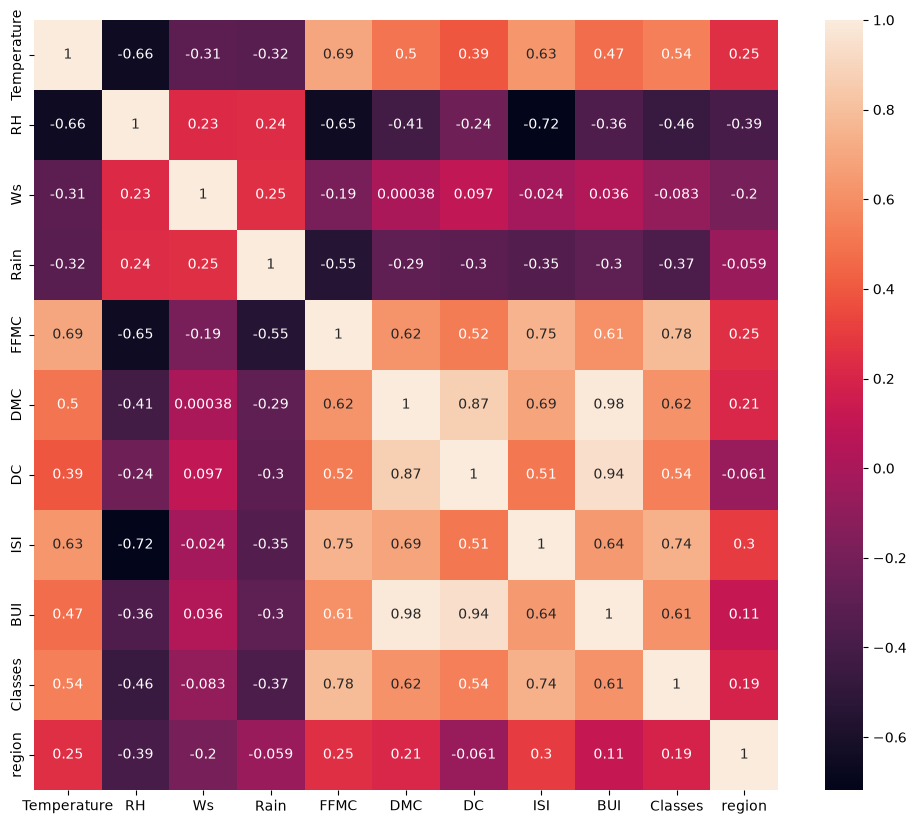

In [45]:
plt.figure(figsize=(12,10))
corr= X_train.corr()
sns.heatmap(corr, annot=True)

In [46]:
def correlation(dataset, threshold):
    col_corr= set() # Set of all the names of deleted columns
    corr_matrix= dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold: # we are interested in absolute coeff value
                colname= corr_matrix.columns[i] # getting the name of column
                col_corr.add(colname)
    return col_corr

In [47]:
corr_feature=correlation(X_train, 0.80)
corr_feature

{'BUI', 'DC'}

In [48]:
# drop feature when correlation is more than 0.85
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [50]:
Y_test.head()

24     8.4
6      7.2
152    0.5
232    3.8
238    6.5
Name: FWI, dtype: float64

In [51]:
X_train.drop(corr_feature, axis= 1, inplace=True)
X_test.drop(corr_feature,  axis= 1, inplace=True)

#feature scaling and standarization



In [53]:
from sklearn.preprocessing import StandardScaler

In [54]:
scalar = StandardScaler()

In [75]:
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled= scalar.transform(X_test)

In [61]:
## boxplot to understand  effect of  standard scalar

Text(0.5, 1.0, 'X_train After Scaling')

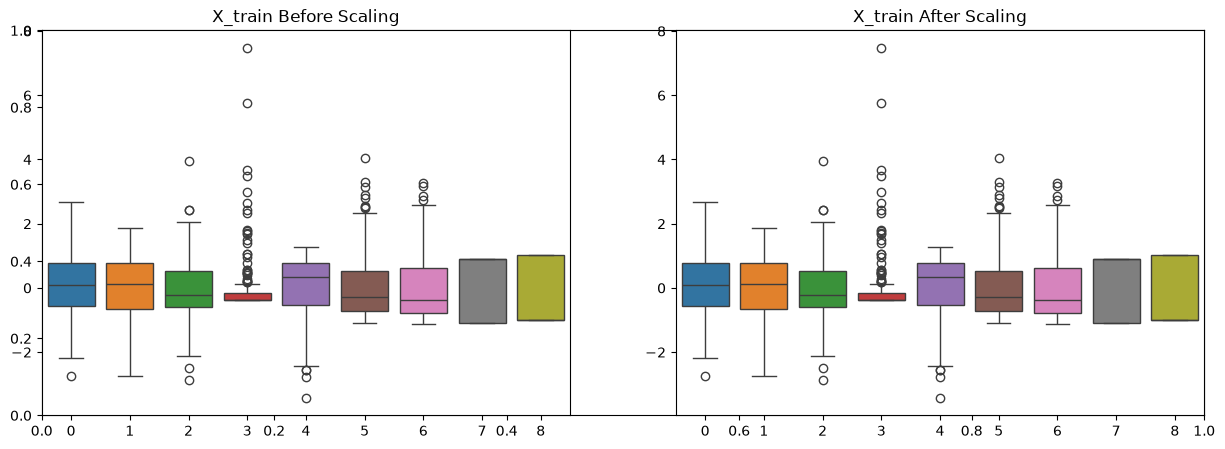

In [76]:
plt.subplots(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=X_train)
plt.title('X_train Before Scaling')
plt.subplot(1, 2, 2)
sns.boxplot(data=X_train_scaled)
plt.title('X_train After Scaling')

Linear Regression Model

In [82]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
linear = LinearRegression()
linear.fit(X_train_scaled, Y_train)
y_pred= linear.predict(X_test_scaled)
mae= mean_absolute_error(Y_test, y_pred)
r2score = r2_score(Y_test, y_pred)
mse= mean_squared_error(Y_test, y_pred)

Mean Absolute Error:  0.5468236465249983
R-squared Score:  0.9847657384266951
Mean Squared Error:  0.6742766873791594


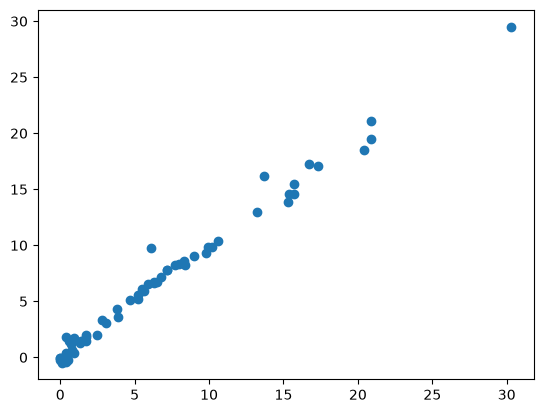

In [85]:
print("Mean Absolute Error: ", mae)
print("R-squared Score: ", r2score)
print("Mean Squared Error: ", mse)
plt.scatter(Y_test, y_pred)

Lasso Regression model


In [86]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
las = Lasso()
las.fit(X_train_scaled, Y_train)
y_pred= las.predict(X_test_scaled)
mae= mean_absolute_error(Y_test, y_pred)
r2score = r2_score(Y_test, y_pred)
mse= mean_squared_error(Y_test, y_pred)

Mean Absolute Error:  1.133175994914409
R-squared Score:  0.9492020263112388
Mean Squared Error:  2.2483458918974764


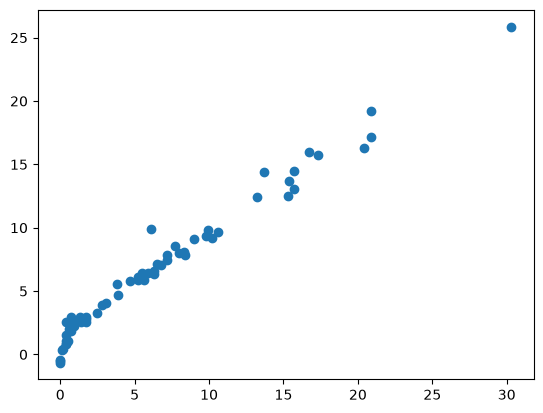

In [87]:
print("Mean Absolute Error: ", mae)
print("R-squared Score: ", r2score)
print("Mean Squared Error: ", mse)
plt.scatter(Y_test, y_pred)

Cross Validation Lasso


In [ ]:
from sklearn.linear_model import LassoCV
lassocv= LassoCV(cv=5)
lassocv.fit(X_train_scaled, Y_train)


100

In [96]:
lassocv.alpha_

np.float64(0.06582808719529475)

In [95]:
lassocv.alphas_

array([7.05853002, 6.58280872, 6.13914944, 5.72539132, 5.33951911,
       4.97965339, 4.64404142, 4.33104857, 4.03915039, 3.76692517,
       3.51304702, 3.27627941, 3.05546914, 2.84954075, 2.65749124,
       2.47838523, 2.31135036, 2.15557308, 2.01029467, 1.87480753,
       1.74845178, 1.63061198, 1.52071419, 1.41822315, 1.32263965,
       1.23349817, 1.15036452, 1.0728338 , 1.00052839, 0.93309613,
       0.87020857, 0.81155943, 0.75686304, 0.705853  , 0.65828087,
       0.61391494, 0.57253913, 0.53395191, 0.49796534, 0.46440414,
       0.43310486, 0.40391504, 0.37669252, 0.3513047 , 0.32762794,
       0.30554691, 0.28495408, 0.26574912, 0.24783852, 0.23113504,
       0.21555731, 0.20102947, 0.18748075, 0.17484518, 0.1630612 ,
       0.15207142, 0.14182231, 0.13226397, 0.12334982, 0.11503645,
       0.10728338, 0.10005284, 0.09330961, 0.08702086, 0.08115594,
       0.0756863 , 0.0705853 , 0.06582809, 0.06139149, 0.05725391,
       0.05339519, 0.04979653, 0.04644041, 0.04331049, 0.04039

In [97]:
lassocv.mse_path_

array([[54.04680834, 65.39074075, 54.89628985, 77.90299066, 39.38236846],
       [46.99139504, 59.81506814, 49.29840831, 75.6645852 , 35.31758355],
       [41.14908917, 53.9178721 , 42.49594889, 68.35708298, 31.76996123],
       [36.05788169, 48.41773965, 36.66879347, 61.92819453, 28.67296816],
       [31.62067285, 42.76466229, 31.68391904, 56.26841266, 24.93183295],
       [27.75285367, 37.81922812, 27.42599138, 51.28216115, 21.56888645],
       [24.3807738 , 33.49107651, 23.7950306 , 45.25481907, 18.66094162],
       [21.44052804, 29.70161639, 20.70460191, 39.90418045, 16.14837778],
       [18.876308  , 26.38208059, 18.07969934, 35.23429953, 13.97821475],
       [16.63960395, 23.47341883, 15.85530749, 31.15712074, 12.10483403],
       [14.68819307, 20.92329068, 13.97555108, 27.59649208, 10.48862803],
       [12.98525144, 18.68636627, 12.39173305, 24.48611006,  9.09521221],
       [11.49893734, 16.72312788, 11.06186319, 21.7677198 ,  7.89445038],
       [10.2013182 , 14.9991189 ,  9.9

Mean absolute error 0.6358894638564663
R2 Score 0.9814406737205228


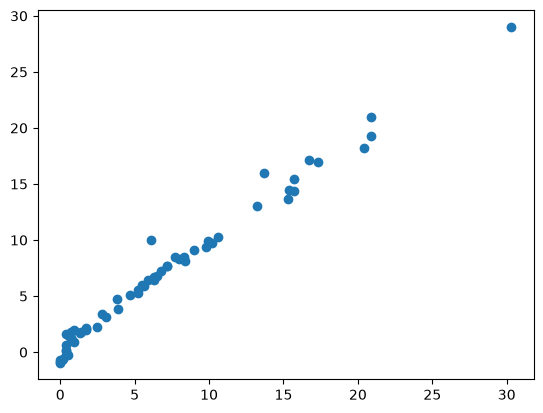

In [100]:
y_pred=lassocv.predict(X_test_scaled)
plt.scatter(Y_test, y_pred)
mae= mean_absolute_error(Y_test, y_pred)
score=r2_score(Y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

Ridge Regression model 

Mean Absolute Error:  0.5642305340105699
R-squared Score:  0.9842993364555513
Mean Squared Error:  0.6949198918152069


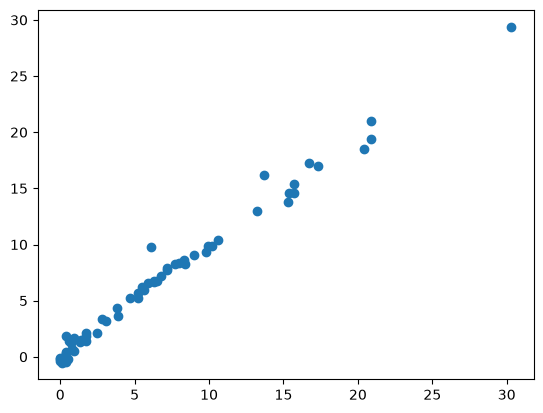

In [88]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
ridge = Ridge()
ridge.fit(X_train_scaled, Y_train)
y_pred= ridge.predict(X_test_scaled)
mae= mean_absolute_error(Y_test, y_pred)
r2score = r2_score(Y_test, y_pred)
mse= mean_squared_error(Y_test, y_pred)
print("Mean Absolute Error: ", mae)
print("R-squared Score: ", r2score)
print("Mean Squared Error: ", mse)
plt.scatter(Y_test, y_pred)

RidgeCV

Mean absolute error 0.5642305340105699
R2 Score 0.9842993364555513


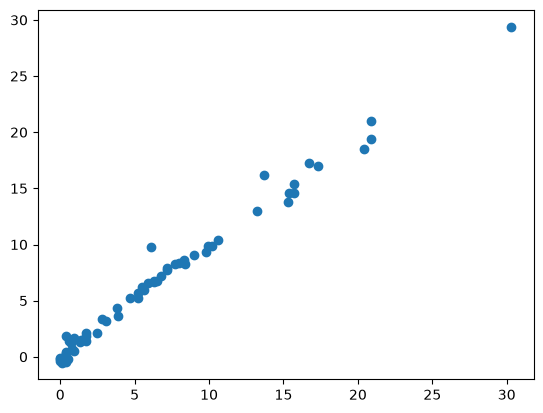

In [102]:
from sklearn.linear_model import RidgeCV
ridgecv= RidgeCV(cv=5)
ridgecv.fit(X_train_scaled, Y_train)
y_pred=ridgecv.predict(X_test_scaled)
plt.scatter(Y_test, y_pred)
mae= mean_absolute_error(Y_test, y_pred)
score=r2_score(Y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

ElasticNet Regression

Mean Absolute Error:  1.8822353634896
R-squared Score:  0.8753460589519703
Mean Squared Error:  5.517251101025224


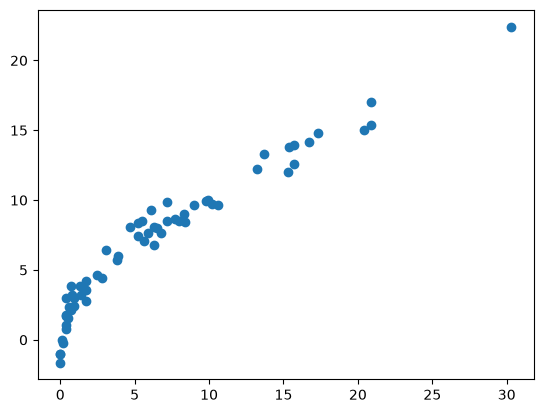

In [90]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
Enet = ElasticNet()
Enet.fit(X_train_scaled, Y_train)
y_pred= Enet.predict(X_test_scaled)
mae= mean_absolute_error(Y_test, y_pred)
r2score = r2_score(Y_test, y_pred)
mse= mean_squared_error(Y_test, y_pred)
print("Mean Absolute Error: ", mae)
print("R-squared Score: ", r2score)
print("Mean Squared Error: ", mse)
plt.scatter(Y_test, y_pred)

Elastic CV

Mean absolute error 0.6575946731430902
R2 Score 0.9814217587854941


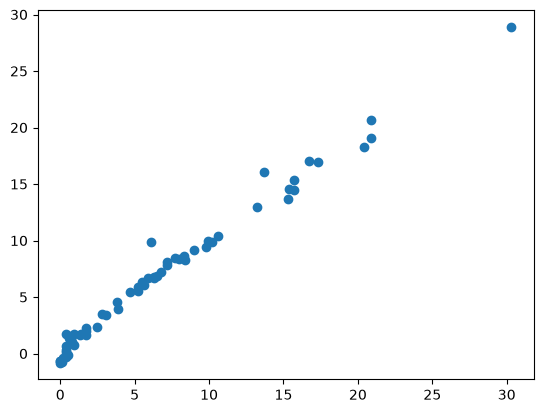

In [103]:
from sklearn.linear_model import ElasticNetCV
elasticnetcv= ElasticNetCV(cv=5)
elasticnetcv.fit(X_train_scaled, Y_train)
y_pred=elasticnetcv.predict(X_test_scaled)
plt.scatter(Y_test, y_pred)
mae= mean_absolute_error(Y_test, y_pred)
score=r2_score(Y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)